<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


In [1]:
pip install matplotlib-inline

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import seaborn as sns

## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)

Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [3]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn


We will import the following libraries for the lab


In [4]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.metrics import roc_auc_score

This function is to plot the confusion matrix.


In [5]:
def plot_confusion_matrix(y,y_predict, model, accuracy):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(f'Confusion Matrix - {model} (Acc: {accuracy:.2f})')
    ax.xaxis.set_ticklabels(['did not land', 'land']); 
    ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [6]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

In [7]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [8]:
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [9]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [10]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 83 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FlightNumber                         90 non-null     float64
 1   PayloadMass                          90 non-null     float64
 2   Flights                              90 non-null     float64
 3   Block                                90 non-null     float64
 4   ReusedCount                          90 non-null     float64
 5   Orbit_ES-L1                          90 non-null     float64
 6   Orbit_GEO                            90 non-null     float64
 7   Orbit_GTO                            90 non-null     float64
 8   Orbit_HEO                            90 non-null     float64
 9   Orbit_ISS                            90 non-null     float64
 10  Orbit_LEO                            90 non-null     float64
 11  Orbit_MEO                            90 non-n

## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [11]:
Y = data['Class'].to_numpy()

In [12]:
import sys

In [13]:
dir(preprocessing)[:10]

['Binarizer',
 'FunctionTransformer',
 'KBinsDiscretizer',
 'KernelCenterer',
 'LabelBinarizer',
 'LabelEncoder',
 'MaxAbsScaler',
 'MinMaxScaler',
 'MultiLabelBinarizer',
 'Normalizer']

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [14]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [16]:
Y_test.shape

(18,)

In [17]:
Y_train.shape

(72,)

we can see we only have 18 test samples.


## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [18]:
LR = LogisticRegression().fit(X_train,Y_train)

In [19]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [20]:
logreg_cv = GridSearchCV(
    estimator=LR, param_grid=parameters, 
    cv=10,  
    scoring='accuracy',  
    n_jobs=-1             
)

In [21]:
logreg_cv.fit(X_train, Y_train)

C:\Users\CARLOS\sklearn-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [22]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [23]:
accuracy = logreg_cv.score(X_test, Y_test)

In [24]:
print("Logistic Regression Accuracy (score method):",accuracy)

Logistic Regression Accuracy (score method): 0.8333333333333334


In [25]:
yhat=logreg_cv.predict(X_test)

In [26]:
mae_logreg = mean_absolute_error(Y_test,yhat)
mse_logreg = mean_squared_error(Y_test,yhat)
rmse_logreg = root_mean_squared_error(Y_test,yhat)
r2_logreg = r2_score(Y_test,yhat)
print(f"Logistic Regression - Mean Absolute Error (MAE): {mae_logreg:.4f}")
print(f"Logistic Regression - Mean Squared Error (MSE): {mse_logreg:.4f}")
print(f"Logistic Regression - Root Mean Squared Error (RMSE): {rmse_logreg:.4f}")
print(f"Logistic Regression - R2 Score (r2): {r2_logreg:.4f}")

Logistic Regression - Mean Absolute Error (MAE): 0.1667
Logistic Regression - Mean Squared Error (MSE): 0.1667
Logistic Regression - Root Mean Squared Error (RMSE): 0.4082
Logistic Regression - R2 Score (r2): 0.2500


In [27]:
report_logreg = classification_report(Y_test,yhat, target_names=["Did not Land", "Landed"])

In [28]:
print(report_logreg)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



Lets look at the confusion matrix:


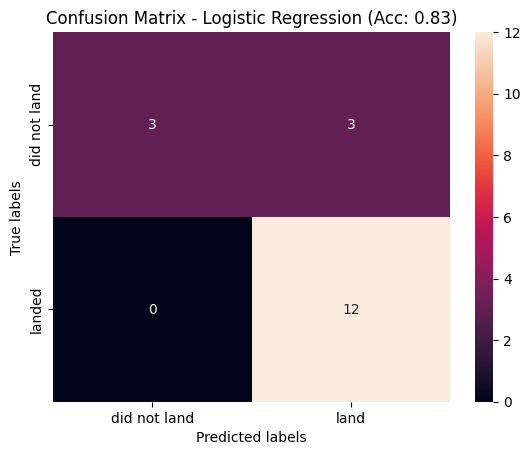

In [29]:
plot_confusion_matrix(Y_test,yhat, 'Logistic Regression', accuracy )

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [30]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [31]:
svm_cv = GridSearchCV(
    estimator=svm, param_grid=parameters, cv=10, # Número de folds da validação cruzada
    scoring='accuracy', # Métrica de avaliação
    n_jobs=-1            # Usa todos os núcleos do processador
)

In [32]:
svm_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [33]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [34]:
accuracy = svm_cv.score(X_test, Y_test)

In [35]:
print("accuracy score method:",accuracy)

accuracy score method: 0.8333333333333334


We can plot the confusion matrix


In [36]:
yhat=svm_cv.predict(X_test)

In [37]:
mae_svm = mean_absolute_error(Y_test,yhat)
mse_svm = mean_squared_error(Y_test,yhat)
rmse_svm = root_mean_squared_error(Y_test,yhat)
r2_svm = r2_score(Y_test,yhat)
print(f"Support Vector Machine - Mean Absolute Error (MAE): {mae_svm:.4f}")
print(f"Support Vector Machine - Mean Squared Error (MSE): {mse_svm:.4f}")
print(f"Support Vector Machine - Root Mean Squared Error (RMSE): {rmse_svm:.4f}")
print(f"Support Vector Machine - R2 Score (r2): {r2_svm:.4f}")

Support Vector Machine - Mean Absolute Error (MAE): 0.1667
Support Vector Machine - Mean Squared Error (MSE): 0.1667
Support Vector Machine - Root Mean Squared Error (RMSE): 0.4082
Support Vector Machine - R2 Score (r2): 0.2500


In [38]:
report_svm = classification_report(Y_test,yhat, target_names=["Did not Land", "Landed"])

In [39]:
print(report_svm)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



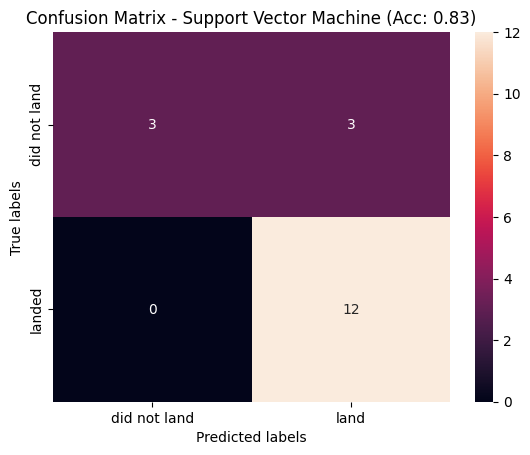

In [40]:
plot_confusion_matrix(Y_test,yhat,'Support Vector Machine', accuracy )

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [41]:
# parameters = {'criterion': ['gini', 'entropy'],
#     'splitter': ['best', 'random'],
parameters = {'criterion': ['gini'],
     'splitter': ['best'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['log2', 'sqrt'],             
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [42]:
tree_cv = GridSearchCV(
    estimator=tree, param_grid=parameters, cv=10, # Número de folds da validação cruzada
    scoring='accuracy', # Métrica de avaliação
    n_jobs=-1,         # Usa todos os núcleos do processador
    error_score='raise'  # se um ajuste falhar, o erro será exibido
)

In [43]:
tree_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini'], 'max_depth': [2, 4, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [44]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.8714285714285713


In [45]:
y_pred_tree = tree_cv.predict_proba(X_test)[:,1]

In [46]:
roc_auc_tree = roc_auc_score(Y_test, y_pred_tree)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_tree))

SVM ROC-AUC score: 0.750


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [47]:
accuracy = tree_cv.score(X_test, Y_test)
print("accuracy score method:",accuracy)

accuracy score method: 0.8333333333333334


We can plot the confusion matrix


In [48]:
yhat = tree_cv.predict(X_test)

In [49]:
mae_tree = mean_absolute_error(Y_test,yhat)
mse_tree = mean_squared_error(Y_test,yhat)
rmse_tree = root_mean_squared_error(Y_test,yhat)
r2_tree = r2_score(Y_test,yhat)
print(f"Decision Tree Classifier - Mean Absolute Error (MAE): {mae_tree:.4f}")
print(f"Decision Tree Classifier - Mean Squared Error (MSE): {mse_tree:.4f}")
print(f"Decision Tree Classifier - Root Mean Squared Error (RMSE): {rmse_tree:.4f}")
print(f"Decision Tree Classifier - R2 Score (r2): {r2_tree:.4f}")

Decision Tree Classifier - Mean Absolute Error (MAE): 0.1667
Decision Tree Classifier - Mean Squared Error (MSE): 0.1667
Decision Tree Classifier - Root Mean Squared Error (RMSE): 0.4082
Decision Tree Classifier - R2 Score (r2): 0.2500


In [50]:
report_tree = classification_report(Y_test,yhat, target_names=["Did not Land", "Landed"])

In [51]:
print(report_tree)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



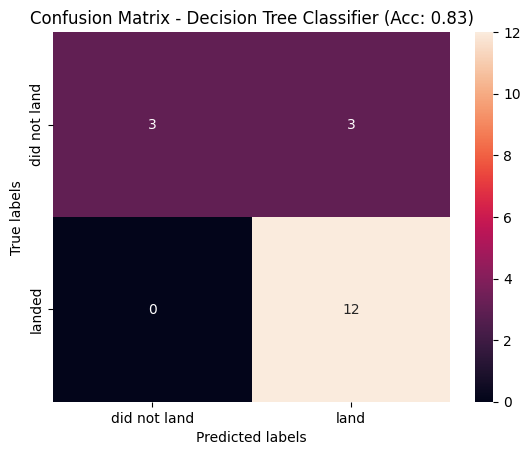

In [52]:
plot_confusion_matrix(Y_test,yhat,'Decision Tree Classifier', accuracy)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [53]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [54]:
knn_cv = GridSearchCV(
    estimator=KNN, param_grid=parameters, cv=10, # Número de folds da validação cruzada
    scoring='accuracy', # Métrica de avaliação
    n_jobs=-1            # Usa todos os núcleos do processador
)

In [55]:
knn_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [56]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [57]:
accuracy = knn_cv.score(X_test, Y_test)
print("accuracy score method:",accuracy)

accuracy score method: 0.8333333333333334


We can plot the confusion matrix


In [58]:
yhat = knn_cv.predict(X_test)

In [59]:
mae_knn = mean_absolute_error(Y_test,yhat)
mse_knn = mean_squared_error(Y_test,yhat)
rmse_knn = root_mean_squared_error(Y_test,yhat)
r2_knn = r2_score(Y_test,yhat)
print(f"K Nearest Neighbors - Mean Absolute Error (MAE): {mae_knn:.4f}")
print(f"K Nearest Neighbors - Mean Squared Error (MSE): {mse_knn:.4f}")
print(f"K Nearest Neighbors - Root Mean Squared Error (RMSE): {rmse_knn:.4f}")
print(f"K Nearest Neighbors - R2 Score (r2): {r2_knn:.4f}")

K Nearest Neighbors - Mean Absolute Error (MAE): 0.1667
K Nearest Neighbors - Mean Squared Error (MSE): 0.1667
K Nearest Neighbors - Root Mean Squared Error (RMSE): 0.4082
K Nearest Neighbors - R2 Score (r2): 0.2500


In [60]:
report_knn = classification_report(Y_test,yhat, target_names=["Did not Land", "Landed"])

In [61]:
print(report_knn)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



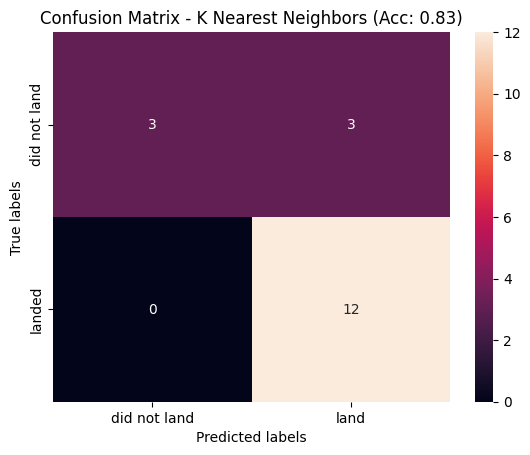

In [62]:

plot_confusion_matrix(Y_test,yhat,'K Nearest Neighbors',accuracy )

## TASK  12


Find the method performs best:


In [63]:
print(f"Logistical Regression Accuracy : {logreg_cv.best_score_:.5f}")
print(f"Support Vector Machine Accuracy : {svm_cv.best_score_:.5f}")
print(f"Decision Tree Classifier Accuracy : {tree_cv.best_score_:.5f}")
print(f"K Nearest Neighbors Accuracy : {knn_cv.best_score_:.5f}")

Logistical Regression Accuracy : 0.84643
Support Vector Machine Accuracy : 0.84821
Decision Tree Classifier Accuracy : 0.87143
K Nearest Neighbors Accuracy : 0.84821


### Classification metrics

#### Logistic Regression

In [64]:
print(report_logreg)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [65]:
print(f"Logistic Regression - Mean Absolute Error (MAE): {mae_logreg:.5f}")
print(f"Logistic Regression - Mean Squared Error (MSE): {mse_logreg:.5f}")
print(f"Logistic Regression - Root Mean Squared Error (RMSE): {rmse_logreg:.5f}")
print(f"Logistic Regression - R2 Score (r2): {r2_logreg:.5f}")

Logistic Regression - Mean Absolute Error (MAE): 0.16667
Logistic Regression - Mean Squared Error (MSE): 0.16667
Logistic Regression - Root Mean Squared Error (RMSE): 0.40825
Logistic Regression - R2 Score (r2): 0.25000


#### Support Vector MachineLogistic Regression SVM

In [66]:
print(report_svm)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [67]:
print(f"Support Vector Machine - Mean Absolute Error (MAE): {mae_svm:.5f}")
print(f"Support Vector Machine - Mean Squared Error (MSE): {mse_svm:.5f}")
print(f"Support Vector Machine - Root Mean Squared Error (RMSE): {rmse_svm:.5f}")
print(f"Support Vector Machine - R2 Score (r2): {r2_svm:.5f}")

Support Vector Machine - Mean Absolute Error (MAE): 0.16667
Support Vector Machine - Mean Squared Error (MSE): 0.16667
Support Vector Machine - Root Mean Squared Error (RMSE): 0.40825
Support Vector Machine - R2 Score (r2): 0.25000


#### Decision Tree Classifier

In [68]:
print(f"Decision Tree Classifier - Mean Absolute Error (MAE): {mae_tree:.5f}")
print(f"Decision Tree Classifier - Mean Squared Error (MSE): {mse_tree:.5f}")
print(f"Decision Tree Classifier - Root Mean Squared Error (RMSE): {rmse_tree:.5f}")
print(f"Decision Tree Classifier - R2 Score (r2): {r2_tree:.5f}")

Decision Tree Classifier - Mean Absolute Error (MAE): 0.16667
Decision Tree Classifier - Mean Squared Error (MSE): 0.16667
Decision Tree Classifier - Root Mean Squared Error (RMSE): 0.40825
Decision Tree Classifier - R2 Score (r2): 0.25000


In [69]:
print(report_tree)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



#### K Nearest Neighbors 

In [70]:
print(report_knn)

              precision    recall  f1-score   support

Did not Land       1.00      0.50      0.67         6
      Landed       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [71]:
print(f"K Nearest Neighbors - Mean Absolute Error (MAE): {mae_knn:.5f}")
print(f"K Nearest Neighbors - Mean Squared Error (MSE): {mse_knn:.5f}")
print(f"K Nearest Neighbors - Root Mean Squared Error (RMSE): {rmse_knn:.5f}")
print(f"K Nearest Neighbors - R2 Score (r2): {r2_knn:.5f}")

K Nearest Neighbors - Mean Absolute Error (MAE): 0.16667
K Nearest Neighbors - Mean Squared Error (MSE): 0.16667
K Nearest Neighbors - Root Mean Squared Error (RMSE): 0.40825
K Nearest Neighbors - R2 Score (r2): 0.25000


The comparison of the models using best_score_ from cross-validation shows that Decision Tree had the highest accuracy (85.7%). 

The SVM and KNN models were practically the same (~84.8%), and Logistic Regression had the lowest value, although the difference is small (84.6%).

The Decision Tree appears to be the best model according to cross-validation, but the difference is small (1%).

This suggests that all models have similar performance. The test set used is relatively small (18 samples), which may limit the reliability of the performance metrics. Small variations in predictions can cause significant changes in accuracy.

Although different algorithms were tested, all produced identical results on the test set, suggesting that the problem may be relatively simple or that the size of the dataset limits the ability to distinguish performance between models.

The recall for the Did not Land class is relatively low (0.50), indicating that the model fails to correctly identify half of the cases in which the rocket does not land. Predicting that a rocket will land when it will not can be very costly. 

For this application, this could represent a significant risk and suggests the need for improvements to the model or data balancing.

## Appendix: Determining the cost by applying the calculated success rate

#### 1.) Using only recovery sucess rate

Example of calculation reasoning for determining the cost by applying the first-stage recovery success rate

In [103]:
recovery_rate = np.mean(Y)
print(f"Historical Recovery Rate : {recovery_rate:.4f}")

Historical Recovery Rate : 0.6667


In [78]:
cost_new = 64      # US$ millions - Hypothetical values

In [79]:
cost_reused = 42   # US$ millions - Hypothetical values for  cost of reuse, cost if recovery attempt fails, indirect cost of attempting landing (less payload) 

In [81]:
expected_cost = cost_new * (1 - recovery_rate) + cost_reused * recovery_rate

In [82]:
print(f"Expected cost (US$ millions) : {expected_cost:.2f}")

Expected cost (US$ millions) : 49.33


#### 2.) Calibrate the historical average

Using confusion matrix metrics to calibrate the historical average

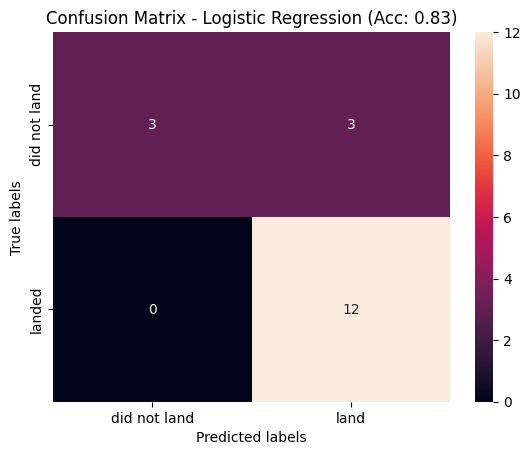

In [83]:
plot_confusion_matrix(Y_test,yhat, 'Logistic Regression', accuracy )

In [92]:
TP = 12
FN = 0
TN = 3 
FP = 3

In [93]:
TPR = TP / (TP + FN)   # hit rate on recoverable items 
FPR = FP / (FP + TN)    # miss rate on non-recoverable items 

In [94]:
recovery_rate_model = recovery_rate * TPR + (1 - recovery_rate) * FPR

In [96]:
expected_cost = cost_new * (1 - recovery_rate_model) + cost_reused * recovery_rate_model
print(f"Expected cost (US$ millions) : {expected_cost:.2f}")

Expected cost (US$ millions) : 45.67


#### 3.) Reuse or Discard decision

Assessing the probability of successful recovery to decide: Reuse (attempt landing) or Discard (use everything for performance).

In [104]:
cost_new = 64           #  cost of a new booster → US$ 64M
cost_reuse = 10         #  cost of reuse (refurbishment) → US$ 10M
cost_fail = 64          #  cost if recovery attempt fails → US$ 64M
cost_fuel_penalty = 5   #  indirect cost of attempting landing (less payload) → US$ 5M

In [105]:
reused_estrategy =  cost_reuse * recovery_rate  + cost_fail  * (1 - recovery_rate) + cost_fuel_penalty
discard_estrategy = cost_new

In [106]:
print(f"Reuse cost (US$ millions): {reused_estrategy:.2f}")
print(f"Discard cost (US$ millions): {discard_estrategy:.2f}")

Reuse cost (US$ millions): 33.00
Discard cost (US$ millions): 64.00


In [107]:
if reused_estrategy < discard_estrategy:
    print(f"Reuse cost (US$ millions): {reused_estrategy:.2f}")
else:
    print(f"Discard cost (US$ millions): {discard_estrategy:.2f}");

Reuse cost (US$ millions): 33.00


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
